In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [40]:
base_credit = pd.read_csv("bases_de_dados/credit_data.csv")

display(base_credit)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [41]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [42]:
base_credit[base_credit['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [43]:
base_credit[base_credit['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


In [44]:
np.unique(base_credit['default'], return_counts='True')

(array([0, 1], dtype=int64), array([1717,  283], dtype=int64))

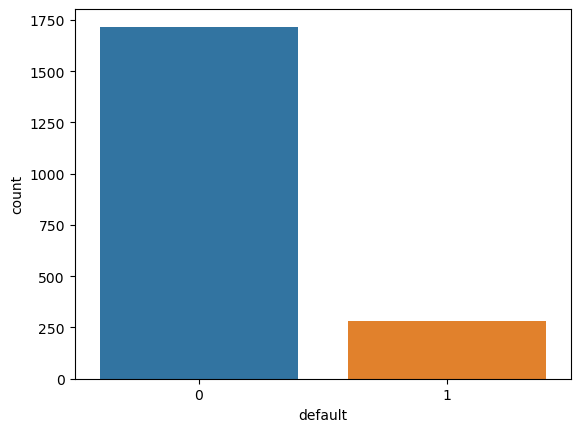

In [45]:
sns.countplot(x = base_credit['default']);

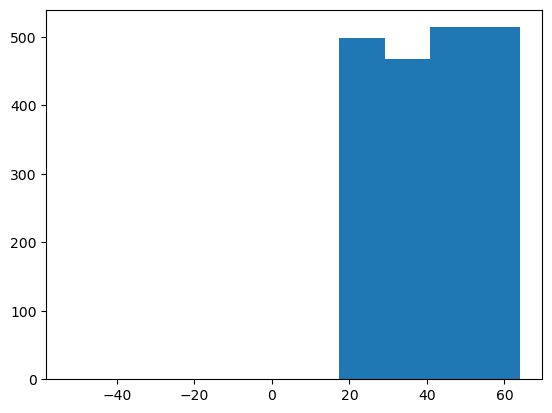

In [46]:
plt.hist(x = base_credit['age']);

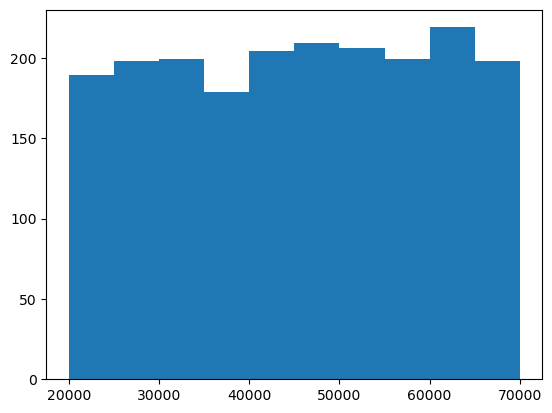

In [47]:
plt.hist(base_credit['income']);

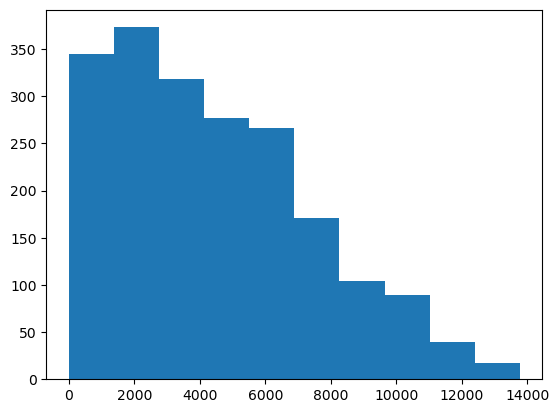

In [48]:
plt.hist(base_credit['loan']);

In [49]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'])
grafico.show()

In [50]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [51]:
base_credit[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


# Apagar a coluna inteira (de todos os registros de dados)

In [52]:
base_credit2 = base_credit.drop('age', axis=1)
base_credit2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


# Apagar somento os registros com valores inconsistentes

In [53]:
base_credit.index # são os índices. Na linha abaixo, dizemos que queremos apagar os "índices" com idade negativa

RangeIndex(start=0, stop=2000, step=1)

In [54]:
base_credit3 = base_credit.drop(base_credit[base_credit['age'] < 0].index)
base_credit3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [55]:
base_credit3.loc[base_credit3['age'] < 0]

,clientid,income,age,loan,default


# Preenches os valores inconsistentes manualmente

In [56]:
base_credit.mean()

clientid     1000.500000
income      45331.600018
age            40.807559
loan         4444.369695
default         0.141500
dtype: float64

In [57]:
base_credit['age'][base_credit['age'] > 0].mean()

40.92770044906149

In [58]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92
base_credit[base_credit['age'] < 0]
base_credit.head(27)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


# Tratamento de valores faltantes

In [59]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [60]:
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [61]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True) # usar o Inplace para substituir as mudanças na base de dados
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default


In [62]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [63]:
x_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values

In [64]:
print(x_credit)
type(x_credit)

[[6.61559251e+04 5.90170151e+01 8.10653213e+03]
 [3.44151540e+04 4.81171531e+01 6.56474502e+03]
 [5.73171701e+04 6.31080495e+01 8.02095330e+03]
 ...
 [4.43114493e+04 2.80171669e+01 5.52278669e+03]
 [4.37560566e+04 6.39717958e+01 1.62272260e+03]
 [6.94365796e+04 5.61526170e+01 7.37883360e+03]]


numpy.ndarray

In [65]:
print(y_credit)
type(y_credit)

[0 0 0 ... 1 0 0]


numpy.ndarray

# Escalonamento: para deixar os valores na mesma escala para não afetar a precisão dos algoritmos preditivos
# Padronização x = (x - media(x)) / desvio padrao(x) ---- Mais indicado para quando temos outliers na base
# Normalização (x - minimo(x)) / maximo(x) - minimo(x)

In [66]:
print(x_credit[:, 0].min())
print(x_credit[:, 0].max())

20014.4894700497
69995.6855783239


In [67]:
print(x_credit[:, 1].min())
print(x_credit[:, 1].max())

18.055188510566897
63.971795841120205


In [68]:
print(x_credit[:, 2].min())
print(x_credit[:, 2].max())

1.37762959325451
13766.0512393337


In [69]:
from sklearn.preprocessing import StandardScaler

scaler_credit = StandardScaler()
x_credit = scaler_credit.fit_transform(x_credit)
x_credit

array([[ 1.45393393,  1.36538093,  1.20281942],
       [-0.76217555,  0.5426602 ,  0.69642695],
       [ 0.83682073,  1.67417189,  1.17471147],
       ...,
       [-0.07122592, -0.97448519,  0.35420081],
       [-0.11000289,  1.73936739, -0.92675625],
       [ 1.682986  ,  1.14917639,  0.96381038]])

In [70]:
x_credit[:, 0].min(), x_credit[:, 1].min(), x_credit[:, 2].min()

(-1.7676158019964077, -1.7264145408889917, -1.4592791099462408)

In [71]:
x_credit[:, 0].max(), x_credit[:, 1].max(), x_credit[:, 2].max()

(1.7220222385319197, 1.7393673928651967, 3.0616609141708273)

# Divisão entre bases de treinamento e teste

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
# random_state para fixar os mesmos registros nas bases de treinamento e teste
x_credit_treinamento, x_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(x_credit, y_credit, test_size=0.25, random_state=0)

In [74]:
x_credit_treinamento.shape

(1500, 3)

In [75]:
y_credit_treinamento.shape

(1500,)

In [76]:
x_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))